# Confidence Analysis

This notebook analyzes model confidence distributions to understand prediction reliability.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_DIR = Path('../processed_data')
MODEL_DIR = Path('../models')
RESULTS_DIR = Path('../results')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

# Configuration
RANDOM_SEED = 42
MAX_LENGTH = 256
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Load Data

In [2]:
# Load test data
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print(f"Test set: {len(test_df):,} reviews")

X_test = test_df['processed_text'].fillna('').values
y_test = test_df['voted_up'].astype(int).values

# Load metadata encoders
encoders = joblib.load(MODEL_DIR / 'metadata_encoders.joblib')
genre_encoder = encoders['genre_encoder']
playtime_tier_encoder = encoders['playtime_tier_encoder']
length_tier_encoder = encoders['length_tier_encoder']

# Encode metadata
genre_ids_test = genre_encoder.transform(test_df['primary_genre'])
playtime_tier_ids_test = playtime_tier_encoder.transform(test_df['playtime_tier'])
length_tier_ids_test = length_tier_encoder.transform(test_df['length_tier'])

NUM_GENRES = len(genre_encoder.classes_)
NUM_PLAYTIME_TIERS = len(playtime_tier_encoder.classes_)
NUM_LENGTH_TIERS = len(length_tier_encoder.classes_)

print(f"Genres: {NUM_GENRES}, Playtime tiers: {NUM_PLAYTIME_TIERS}, Length tiers: {NUM_LENGTH_TIERS}")

Test set: 6,086 reviews
Genres: 12, Playtime tiers: 4, Length tiers: 3


In [26]:
counts = np.bincount(y_test)
percentages = counts / counts.sum() * 100

for label, (cnt, pct) in enumerate(zip(counts, percentages)):
    print(f"Class {label}: {cnt} samples ({pct:.2f}%)")


Class 0: 3043 samples (50.00%)
Class 1: 3043 samples (50.00%)


In [3]:
# Load FastText model
print("Loading FastText model...")
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
EMBEDDING_DIM = ft_model.get_dimension()
print(f"FastText loaded: {EMBEDDING_DIM}-dimensional embeddings")

Loading FastText model...
FastText loaded: 200-dimensional embeddings


## 2. Model Definitions & Dataset

In [4]:
class SteamReviewDatasetWithMetadata(Dataset):
    def __init__(self, texts, labels, genre_ids, playtime_tier_ids, length_tier_ids,
                 ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.genre_ids = genre_ids
        self.playtime_tier_ids = playtime_tier_ids
        self.length_tier_ids = length_tier_ids
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = text.split()[:self.max_length]
        
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'genre_id': torch.tensor(self.genre_ids[idx], dtype=torch.long),
            'playtime_tier_id': torch.tensor(self.playtime_tier_ids[idx], dtype=torch.long),
            'length_tier_id': torch.tensor(self.length_tier_ids[idx], dtype=torch.long)
        }

In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )
    
    def forward(self, gru_output, mask):
        scores = self.attention(gru_output).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e4)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), gru_output).squeeze(1)
        return context, attention_weights


class BiGRUAttentionWithMetadata(nn.Module):
    def __init__(self, embedding_dim=200, hidden_dim=128, num_layers=2, dropout=0.4,
                 num_genres=12, num_playtime_tiers=4, num_length_tiers=3, 
                 metadata_embed_dim=16):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.attention = Attention(hidden_dim * 2)
        
        self.genre_embed = nn.Embedding(num_genres, metadata_embed_dim)
        self.playtime_tier_embed = nn.Embedding(num_playtime_tiers, metadata_embed_dim)
        self.length_tier_embed = nn.Embedding(num_length_tiers, metadata_embed_dim)
        
        combined_dim = hidden_dim * 2 + metadata_embed_dim * 3
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids):
        self.gru.flatten_parameters()
        gru_output, _ = self.gru(embeddings)
        text_context, _ = self.attention(gru_output, mask)
        
        genre_emb = self.genre_embed(genre_ids)
        playtime_emb = self.playtime_tier_embed(playtime_tier_ids)
        length_emb = self.length_tier_embed(length_tier_ids)
        
        combined = torch.cat([text_context, genre_emb, playtime_emb, length_emb], dim=-1)
        return self.classifier(combined)


class TextCNNWithMetadata(nn.Module):
    def __init__(self, embedding_dim=200, n_filters=128, filter_sizes=[3, 4, 5],
                 hidden_dim=128, dropout=0.3,
                 num_genres=12, num_playtime_tiers=4, num_length_tiers=3,
                 metadata_embed_dim=16):
        super().__init__()
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, 
                      out_channels=n_filters,
                      kernel_size=fs) 
            for fs in filter_sizes
        ])
        
        self.genre_embed = nn.Embedding(num_genres, metadata_embed_dim)
        self.playtime_tier_embed = nn.Embedding(num_playtime_tiers, metadata_embed_dim)
        self.length_tier_embed = nn.Embedding(num_length_tiers, metadata_embed_dim)
        
        cnn_output_dim = n_filters * len(filter_sizes)
        combined_dim = cnn_output_dim + metadata_embed_dim * 3
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids):
        masked_embeddings = embeddings * mask.unsqueeze(-1)
        x = masked_embeddings.permute(0, 2, 1)
        
        conved = [F.relu(conv(x)) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        text_features = torch.cat(pooled, dim=1)
        
        genre_emb = self.genre_embed(genre_ids)
        playtime_emb = self.playtime_tier_embed(playtime_tier_ids)
        length_emb = self.length_tier_embed(length_tier_ids)
        
        combined = torch.cat([text_features, genre_emb, playtime_emb, length_emb], dim=-1)
        return self.classifier(combined)

## 3. Load Models

In [6]:
# Load hyperparameters
with open(RESULTS_DIR / 'bigru_metadata_optuna_best_params.json', 'r') as f:
    bigru_params = json.load(f)['best_params']

with open(RESULTS_DIR / 'textcnn_metadata_optuna_best_params.json', 'r') as f:
    textcnn_params = json.load(f)['best_params']

print("BiGRU params:", bigru_params)
print("TextCNN params:", textcnn_params)

BiGRU params: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.20068592388224113, 'learning_rate': 0.0016732285791048196, 'weight_decay': 0.00013399625935258818, 'batch_size': 32, 'metadata_embed_dim': 32}
TextCNN params: {'n_filters': 256, 'filter_sizes': '3,4,5', 'hidden_dim': 64, 'dropout': 0.32699416540205284, 'learning_rate': 0.0009783547650967232, 'weight_decay': 0.0074634960348585015, 'batch_size': 128, 'metadata_embed_dim': 32}


In [7]:
# Load Naive Bayes baseline
print("Loading Naive Bayes model...")
nb_pipeline = joblib.load(MODEL_DIR / 'baseline.joblib')
print("Naive Bayes loaded.")

Loading Naive Bayes model...
Naive Bayes loaded.


In [9]:
# Load BiGRU model
print("Loading BiGRU+Attention+Metadata model...")
bigru_checkpoint = torch.load(MODEL_DIR / 'bigru_attention_metadata.pt', map_location=device)

if 'model_state_dict' in bigru_checkpoint:
    bigru_state_dict = bigru_checkpoint['model_state_dict']
    bigru_config = bigru_checkpoint.get('config', bigru_params)
else:
    bigru_state_dict = bigru_checkpoint
    bigru_config = bigru_params

bigru_model = BiGRUAttentionWithMetadata(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=bigru_config.get('hidden_dim', bigru_params['hidden_dim']),
    num_layers=bigru_config.get('num_layers', bigru_params['num_layers']),
    dropout=bigru_config.get('dropout', bigru_params['dropout']),
    num_genres=NUM_GENRES,
    num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS,
    metadata_embed_dim=bigru_config.get('metadata_embed_dim', bigru_params['metadata_embed_dim'])
).to(device)

bigru_model.load_state_dict(bigru_state_dict)
bigru_model.eval()
print("BiGRU model loaded.")

Loading BiGRU+Attention+Metadata model...
BiGRU model loaded.


In [10]:
# Load TextCNN model
print("Loading TextCNN+Metadata model...")
textcnn_checkpoint = torch.load(MODEL_DIR / 'textcnn_metadata.pt', map_location=device)

if 'model_state_dict' in textcnn_checkpoint:
    textcnn_state_dict = textcnn_checkpoint['model_state_dict']
    textcnn_config = textcnn_checkpoint.get('config', textcnn_params)
else:
    textcnn_state_dict = textcnn_checkpoint
    textcnn_config = textcnn_params

# Parse filter sizes
fs = textcnn_config.get('filter_sizes', textcnn_params['filter_sizes'])
filter_sizes = [int(x) for x in fs.split(',')] if isinstance(fs, str) else fs

textcnn_model = TextCNNWithMetadata(
    embedding_dim=EMBEDDING_DIM,
    n_filters=textcnn_config.get('n_filters', textcnn_params['n_filters']),
    filter_sizes=filter_sizes,
    hidden_dim=textcnn_config.get('hidden_dim', textcnn_params['hidden_dim']),
    dropout=textcnn_config.get('dropout', textcnn_params['dropout']),
    num_genres=NUM_GENRES,
    num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS,
    metadata_embed_dim=textcnn_config.get('metadata_embed_dim', textcnn_params['metadata_embed_dim'])
).to(device)

textcnn_model.load_state_dict(textcnn_state_dict)
textcnn_model.eval()
print("TextCNN model loaded.")

Loading TextCNN+Metadata model...
TextCNN model loaded.


## 4. Get Predictions & Probabilities

In [11]:
# Naive Bayes predictions
print("Getting Naive Bayes predictions...")
nb_probs = nb_pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class
nb_preds = (nb_probs > 0.5).astype(int)
print(f"Naive Bayes accuracy: {(nb_preds == y_test).mean():.4f}")

Getting Naive Bayes predictions...
Naive Bayes accuracy: 0.8598


In [12]:
# Create test dataloader
test_dataset = SteamReviewDatasetWithMetadata(
    X_test, y_test, genre_ids_test, playtime_tier_ids_test, length_tier_ids_test,
    ft_model, MAX_LENGTH
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [13]:
def get_predictions(model, dataloader, device):
    """Get predictions and probabilities from a PyTorch model."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Predicting'):
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            genre_ids = batch['genre_id'].to(device)
            playtime_tier_ids = batch['playtime_tier_id'].to(device)
            length_tier_ids = batch['length_tier_id'].to(device)
            
            with autocast(device_type=device.type):
                logits = model(embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids).squeeze(-1)
            
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_probs), np.array(all_labels)

In [14]:
# BiGRU predictions
print("Getting BiGRU predictions...")
bigru_probs, _ = get_predictions(bigru_model, test_loader, device)
bigru_preds = (bigru_probs > 0.5).astype(int)
print(f"BiGRU accuracy: {(bigru_preds == y_test).mean():.4f}")

Getting BiGRU predictions...


Predicting: 100%|██████████| 96/96 [00:05<00:00, 18.49it/s]

BiGRU accuracy: 0.9012


In [15]:
# TextCNN predictions
print("Getting TextCNN predictions...")
textcnn_probs, _ = get_predictions(textcnn_model, test_loader, device)
textcnn_preds = (textcnn_probs > 0.5).astype(int)
print(f"TextCNN accuracy: {(textcnn_preds == y_test).mean():.4f}")

Getting TextCNN predictions...


Predicting: 100%|██████████| 96/96 [00:05<00:00, 17.28it/s]

TextCNN accuracy: 0.8776


## 5. Compute Confidence Statistics

In [16]:
def compute_confidence_stats(probs, preds, labels, model_name):
    """Compute confidence statistics for a model."""
    # Confidence = distance from 0.5, scaled to 0-1
    confidence = np.abs(probs - 0.5) * 2
    
    correct_mask = (preds == labels)
    incorrect_mask = ~correct_mask
    
    conf_correct = confidence[correct_mask]
    conf_incorrect = confidence[incorrect_mask]
    
    # High confidence threshold
    high_conf_threshold = 0.9
    
    stats = {
        'model': model_name,
        'accuracy': float(correct_mask.mean()),
        'avg_confidence_correct': float(conf_correct.mean()) if len(conf_correct) > 0 else 0,
        'avg_confidence_incorrect': float(conf_incorrect.mean()) if len(conf_incorrect) > 0 else 0,
        'std_confidence_correct': float(conf_correct.std()) if len(conf_correct) > 0 else 0,
        'std_confidence_incorrect': float(conf_incorrect.std()) if len(conf_incorrect) > 0 else 0,
        'pct_wrong_high_conf': float((confidence[incorrect_mask] > high_conf_threshold).mean() * 100) if len(conf_incorrect) > 0 else 0,
        'num_correct': int(correct_mask.sum()),
        'num_incorrect': int(incorrect_mask.sum())
    }
    
    return stats, confidence, correct_mask

In [17]:
# Compute stats for all models
nb_stats, nb_conf, nb_correct = compute_confidence_stats(nb_probs, nb_preds, y_test, 'Naive Bayes')
bigru_stats, bigru_conf, bigru_correct = compute_confidence_stats(bigru_probs, bigru_preds, y_test, 'BiGRU+Attention+Metadata')
textcnn_stats, textcnn_conf, textcnn_correct = compute_confidence_stats(textcnn_probs, textcnn_preds, y_test, 'TextCNN+Metadata')

all_stats = [nb_stats, bigru_stats, textcnn_stats]

In [23]:
# Display results
print("CONFIDENCE ANALYSIS RESULTS")

for stats in all_stats:
    print(f"\n{stats['model']}:")
    print(f"  Accuracy: {stats['accuracy']:.4f}")
    print(f"  Avg Confidence (Correct):   {stats['avg_confidence_correct']:.4f} ± {stats['std_confidence_correct']:.4f}")
    print(f"  Avg Confidence (Incorrect): {stats['avg_confidence_incorrect']:.4f} ± {stats['std_confidence_incorrect']:.4f}")
    print(f"  % Wrong with Conf > 0.9:    {stats['pct_wrong_high_conf']:.1f}%")

CONFIDENCE ANALYSIS RESULTS

Naive Bayes:
  Accuracy: 0.8598
  Avg Confidence (Correct):   0.5706 ± 0.2608
  Avg Confidence (Incorrect): 0.2644 ± 0.2034
  % Wrong with Conf > 0.9:    0.5%

BiGRU+Attention+Metadata:
  Accuracy: 0.9012
  Avg Confidence (Correct):   0.8408 ± 0.2400
  Avg Confidence (Incorrect): 0.4629 ± 0.3110
  % Wrong with Conf > 0.9:    13.0%

TextCNN+Metadata:
  Accuracy: 0.8776
  Avg Confidence (Correct):   0.9355 ± 0.1689
  Avg Confidence (Incorrect): 0.7119 ± 0.3025
  % Wrong with Conf > 0.9:    43.4%


## 6. Generate Confidence Histograms

In [19]:
def plot_confidence_histogram(confidence, correct_mask, model_name, save_path):
    """Plot confidence histogram for correct vs incorrect predictions."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(0, 1, 21)
    
    ax.hist(confidence[correct_mask], bins=bins, alpha=0.7, label='Correct', color='green', density=True)
    ax.hist(confidence[~correct_mask], bins=bins, alpha=0.7, label='Incorrect', color='red', density=True)
    
    ax.axvline(x=0.9, color='black', linestyle='--', linewidth=1.5, label='High Conf Threshold (0.9)')
    
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Confidence Distribution - {model_name}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

Saved: ..\plots\confidence_histogram_naive_bayes.png


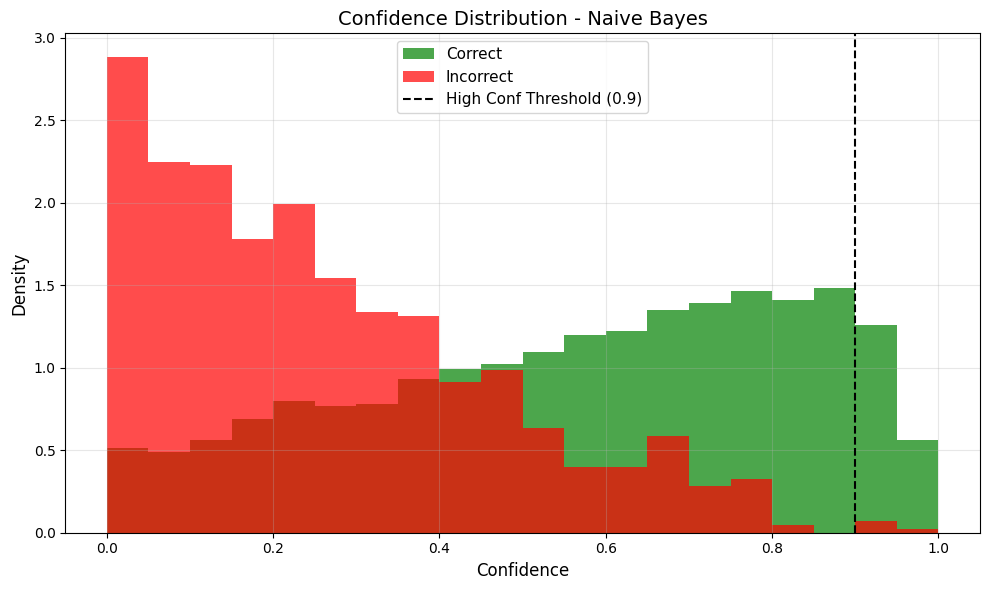

Saved: ..\plots\confidence_histogram_bigru.png


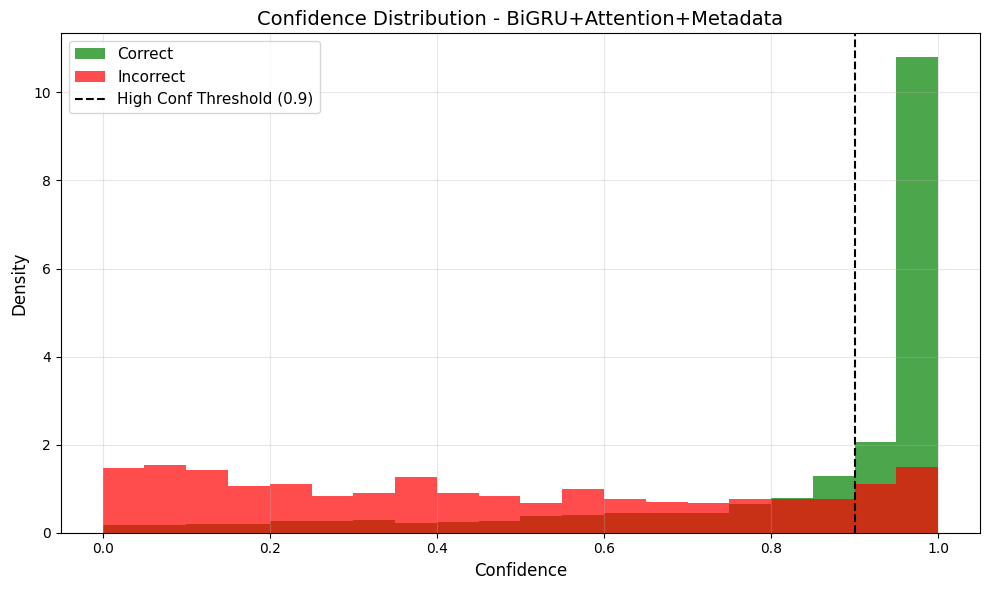

Saved: ..\plots\confidence_histogram_textcnn.png


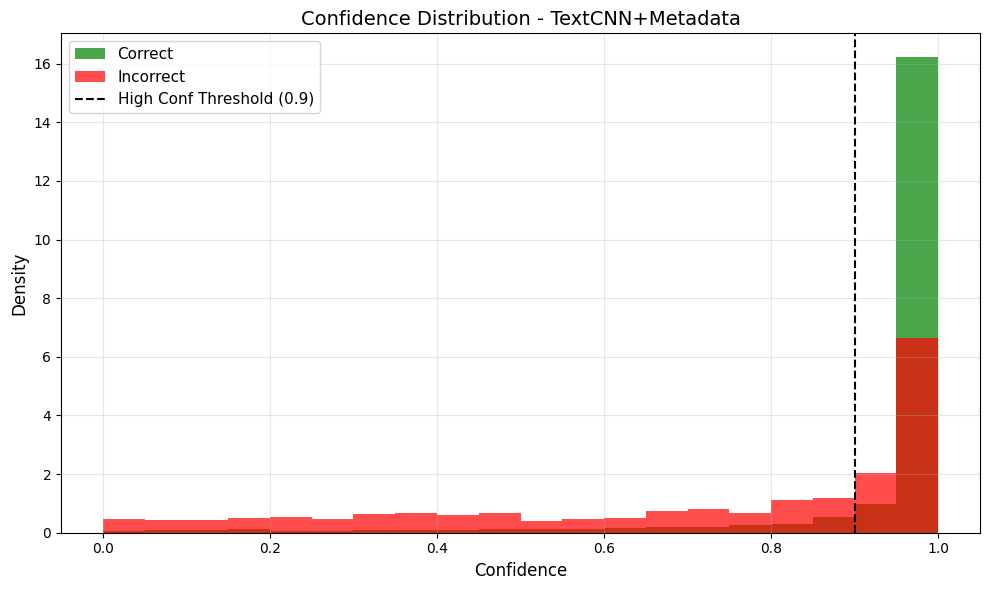

In [20]:
# Plot histograms for all models
plot_confidence_histogram(nb_conf, nb_correct, 'Naive Bayes', PLOTS_DIR / 'confidence_histogram_naive_bayes.png')
plot_confidence_histogram(bigru_conf, bigru_correct, 'BiGRU+Attention+Metadata', PLOTS_DIR / 'confidence_histogram_bigru.png')
plot_confidence_histogram(textcnn_conf, textcnn_correct, 'TextCNN+Metadata', PLOTS_DIR / 'confidence_histogram_textcnn.png')

## 7. Save Results

In [21]:
# Save results to JSON
results = {
    'analysis': 'confidence_distribution',
    'high_conf_threshold': 0.9,
    'models': all_stats
}

with open(RESULTS_DIR / 'confidence_analysis.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to {RESULTS_DIR / 'confidence_analysis.json'}")


Results saved to ..\results\confidence_analysis.json


In [24]:
# Summary table
print("SUMMARY TABLE")
print(f"{'Model':<30} {'Avg Conf (Correct)':<20} {'Avg Conf (Wrong)':<20} {'% Wrong High Conf':<20}")
for stats in all_stats:
    print(f"{stats['model']:<30} {stats['avg_confidence_correct']:.4f}{'':<16} {stats['avg_confidence_incorrect']:.4f}{'':<16} {stats['pct_wrong_high_conf']:.1f}%")

SUMMARY TABLE
Model                          Avg Conf (Correct)   Avg Conf (Wrong)     % Wrong High Conf   
Naive Bayes                    0.5706                 0.2644                 0.5%
BiGRU+Attention+Metadata       0.8408                 0.4629                 13.0%
TextCNN+Metadata               0.9355                 0.7119                 43.4%
